# Zero-Shot Image Classification with CLIP

对任意指定图片进行零样本分类，无需训练。

## 1. 环境准备

In [ ]:
! pip install ftfy regex tqdm
! pip install git+https://github.com/openai/CLIP.git

In [1]:
import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## 2. 加载模型

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

print(f"Available models: {clip.available_models()}")

Using device: cuda
Available models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']


In [3]:
# 选择模型：ViT-B/32 最快，ViT-L/14 最准
model_name = "ViT-B/32"
model, preprocess = clip.load(model_name, device=device)
model.eval()

print(f"Loaded model: {model_name}")
print(f"  Parameters: {np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print(f"  Input resolution: {model.visual.input_resolution}")

Loaded model: ViT-B/32
  Parameters: 151,277,313
  Input resolution: 224


## 3. 设置图片和类别

**修改这里：替换你的图片路径和候选类别。**

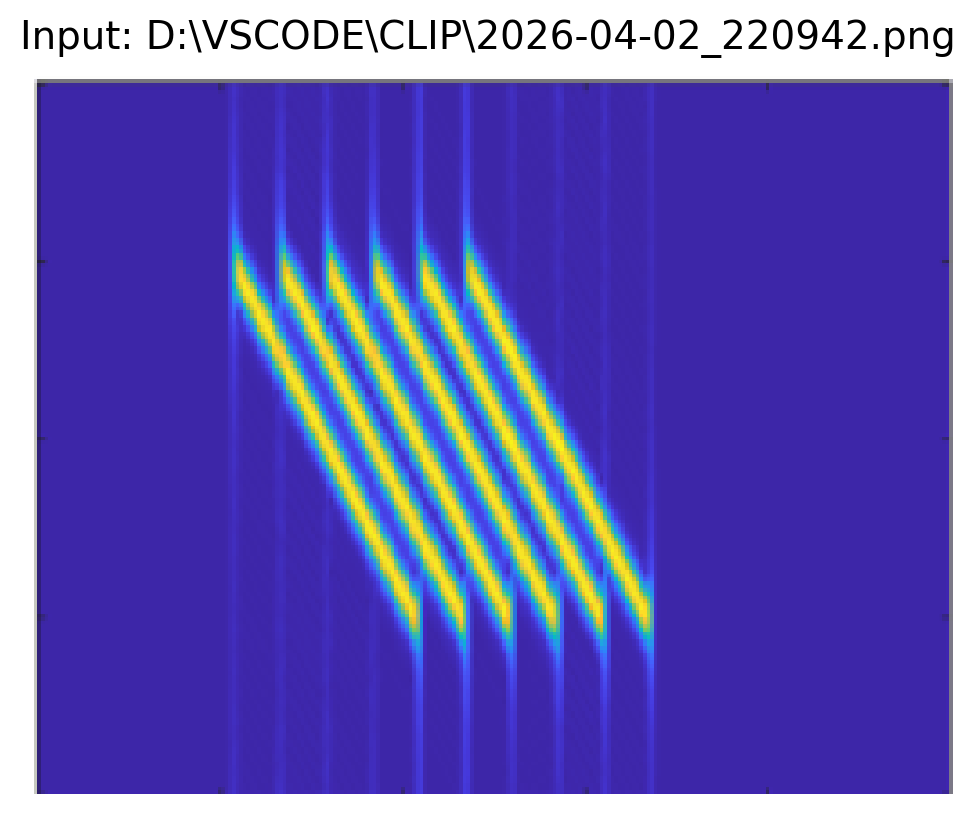

Candidate categories (5):
  1. DFTJ
  2. ISRJ
  3. VDJ
  4. DDJ
  5. slash‌


In [11]:
# ========== 在这里修改图片路径和候选类别 ==========
IMAGE_PATH = r"D:\VSCODE\CLIP\2026-04-02_220942.png"
categories = ["DFTJ", "ISRJ", "VDJ", "DDJ", "slash‌"]
TOP_K = 5
# ==============================================

# 显示原始图片
image = Image.open(IMAGE_PATH).convert("RGB")
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Input: {IMAGE_PATH}", fontsize=14)
plt.show()

print(f"Candidate categories ({len(categories)}):")
for i, cat in enumerate(categories):
    print(f"  {i+1}. {cat}")

## 4. 零样本推理

In [12]:
# 预处理图片：resize + center crop + normalize
image_input = preprocess(image).unsqueeze(0).to(device)

# 用标准提示词模板构建文本
text_templates = [f"a photo of a {c}" for c in categories]
print("Text templates:")
for t in text_templates:
    print(f"  '{t}'")

text_tokens = clip.tokenize(text_templates).to(device)

Text templates:
  'a photo of a DFTJ'
  'a photo of a ISRJ'
  'a photo of a VDJ'
  'a photo of a DDJ'
  'a photo of a slash‌'


In [13]:
# 提取图像和文本特征
with torch.no_grad():
    image_features = model.encode_image(image_input).float()
    text_features = model.encode_text(text_tokens).float()

    # L2 归一化（点积 = 余弦相似度）
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # 余弦相似度 -> softmax 概率
    logits = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    probs, labels = logits.cpu().topk(TOP_K, dim=-1)

print(f"\nResults for: {IMAGE_PATH}")
print("-" * 50)
for rank in range(TOP_K):
    cat = categories[labels[0, rank].item()]
    prob = probs[0, rank].item()
    print(f"  Top-{rank+1}: {cat:20s}  {prob:.2%}")


Results for: D:\VSCODE\CLIP\2026-04-02_220942.png
--------------------------------------------------
  Top-1: ISRJ                  37.33%
  Top-2: VDJ                   31.47%
  Top-3: DFTJ                  12.87%
  Top-4: slash‌                12.84%
  Top-5: DDJ                   5.48%


## 5. 可视化结果


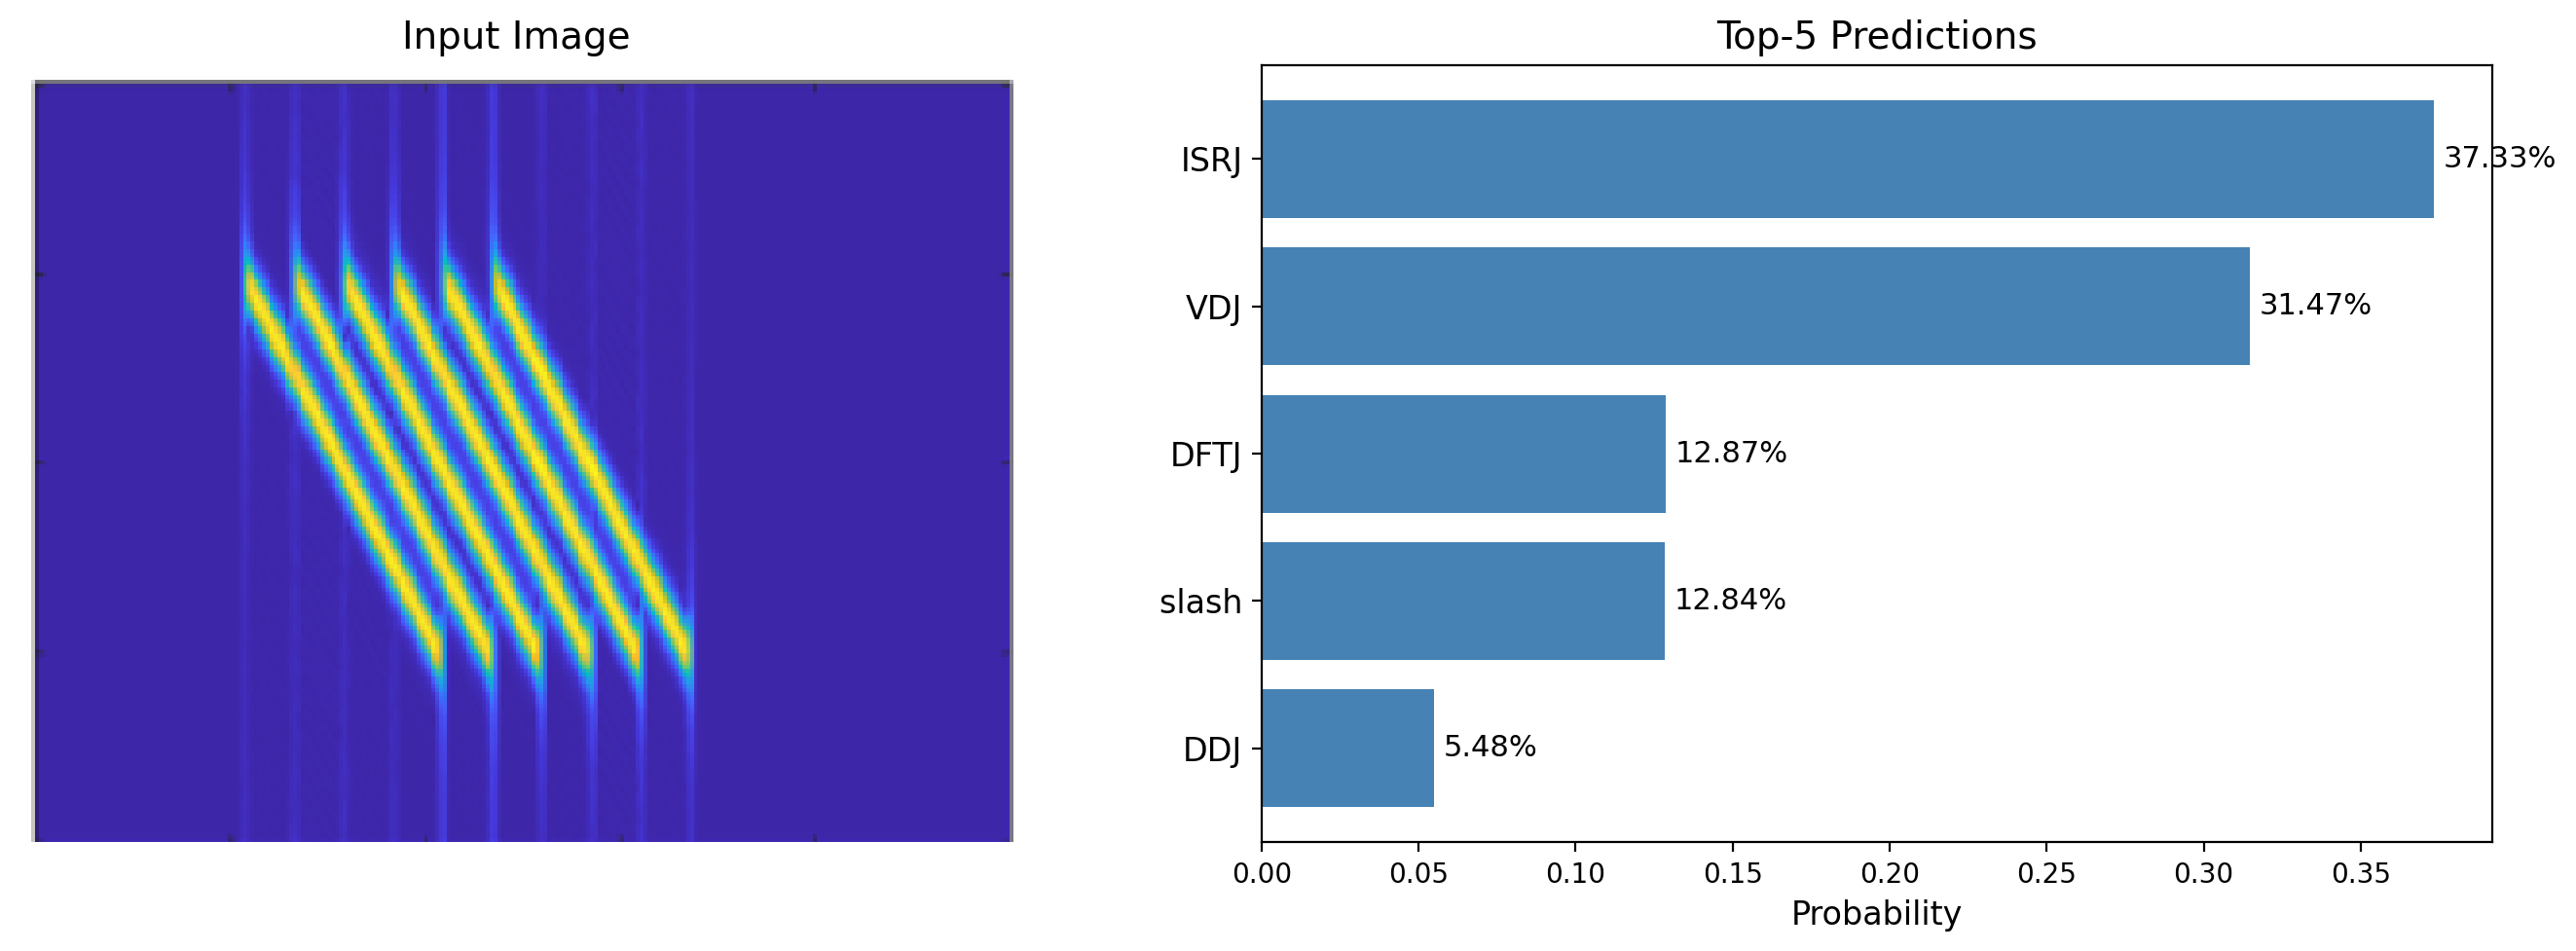

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：原始图片
axes[0].imshow(Image.open(IMAGE_PATH).convert("RGB"))
axes[0].axis("off")
axes[0].set_title("Input Image", fontsize=14)

# 右：Top-K 概率条形图
y = np.arange(TOP_K)
top_cats = [categories[labels[0, i].item()] for i in range(TOP_K)]
top_probs = probs[0].tolist()  # probs shape: (1, TOP_K)，取第0维得到1D列表
bars = axes[1].barh(y[::], top_probs[::-1], color="steelblue")
axes[1].set_yticks(y)
axes[1].set_yticklabels(top_cats[::-1], fontsize=12)
axes[1].set_xlabel("Probability", fontsize=12)
axes[1].set_title("Top-{} Predictions".format(TOP_K), fontsize=14)

# 标注数值
for i, (bar, val) in enumerate(zip(bars, top_probs[::-1])):
    axes[1].text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                 f"{val:.2%}", va="center", fontsize=11)

plt.tight_layout()
plt.show()

## 6. 批量图片识别（可选）

对多张图片同时进行分类。

In [ ]:
import os
from pathlib import Path

# 指定图片目录
IMAGE_DIR = "./val_images"
exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
image_paths = [p for p in Path(IMAGE_DIR).glob("*") if p.suffix.lower() in exts]

print(f"Found {len(image_paths)} images")

# 批量预处理
batch_inputs = []
for p in image_paths:
    try:
        img = preprocess(Image.open(p).convert("RGB"))
        batch_inputs.append(img)
    except Exception as e:
        print(f"  Warning: could not load {p}: {e}")

if not batch_inputs:
    print("No valid images. Skipping batch processing.")
else:
    batch_tensor = torch.stack(batch_inputs).to(device)
    print(f"Processing {len(batch_tensor)} images...")

    # 构建文本特征（只需一次）
    text_templates = [f"a photo of a {c}" for c in categories]
    text_tokens = clip.tokenize(text_templates).to(device)
    with torch.no_grad():
        text_f = model.encode_text(text_tokens).float()
        text_f /= text_f.norm(dim=-1, keepdim=True)

        image_f = model.encode_image(batch_tensor).float()
        image_f /= image_f.norm(dim=-1, keepdim=True)

        probs = (100.0 * image_f @ text_f.T).softmax(dim=-1)

    # 打印结果
    for i, p in enumerate(image_paths[:len(batch_inputs)]):
        top_prob, top_label = probs[i].topk(1)
        cat = categories[top_label.item()]
        prob = top_prob.item()
        print(f"  {p.name:30s} => {cat:15s} ({prob:.2%})")